# Historical OHLCV analysis

Download data from the project root before running this notebook, for example:

```bash
./pyenv/bin/python -m trading history download --dataset-id btcusdt-1h --instrument crypto:binance:spot:BTCUSDT --symbol BTCUSDT --interval 1h --start 2026-01-01T00:00:00+00:00 --end 2026-07-01T00:00:00+00:00
```

In [1]:
from pathlib import Path
from trading.history import BarRepository

project_root = Path.cwd()
if not (project_root / "pyproject.toml").exists():
    project_root = project_root.parent
repository = BarRepository(project_root / "data/history")
available = repository.datasets()
if not available:
    raise RuntimeError("No historical datasets found. Run the download command in the first cell.")
dataset_id = available[0]  # Or replace this with a specific dataset id.
print("Available datasets:", available)
data = repository.load(dataset_id)
df = data.frame()
df.tail()

Available datasets: ('btcusdt-1h',)


,open,high,low,close,volume
time,,,,,
2026-06-30 19:00:00+00:00,58680.86,58839.16,58586.01,58818.05,678.64150
2026-06-30 20:00:00+00:00,58818.00,58874.99,58648.26,58732.01,428.82351
2026-06-30 21:00:00+00:00,58732.00,58770.00,58509.99,58639.99,398.14222
2026-06-30 22:00:00+00:00,58639.99,58806.91,58513.80,58607.99,274.43078
2026-06-30 23:00:00+00:00,58607.99,58664.00,58555.00,58624.71,551.65078


Matplotlib is building the font cache; this may take a moment.
/Users/zhaoqian/Code/Github/trader/pyenv/lib/python3.14/site-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+
findfont: Failed to find font weight semibold, now using 700.


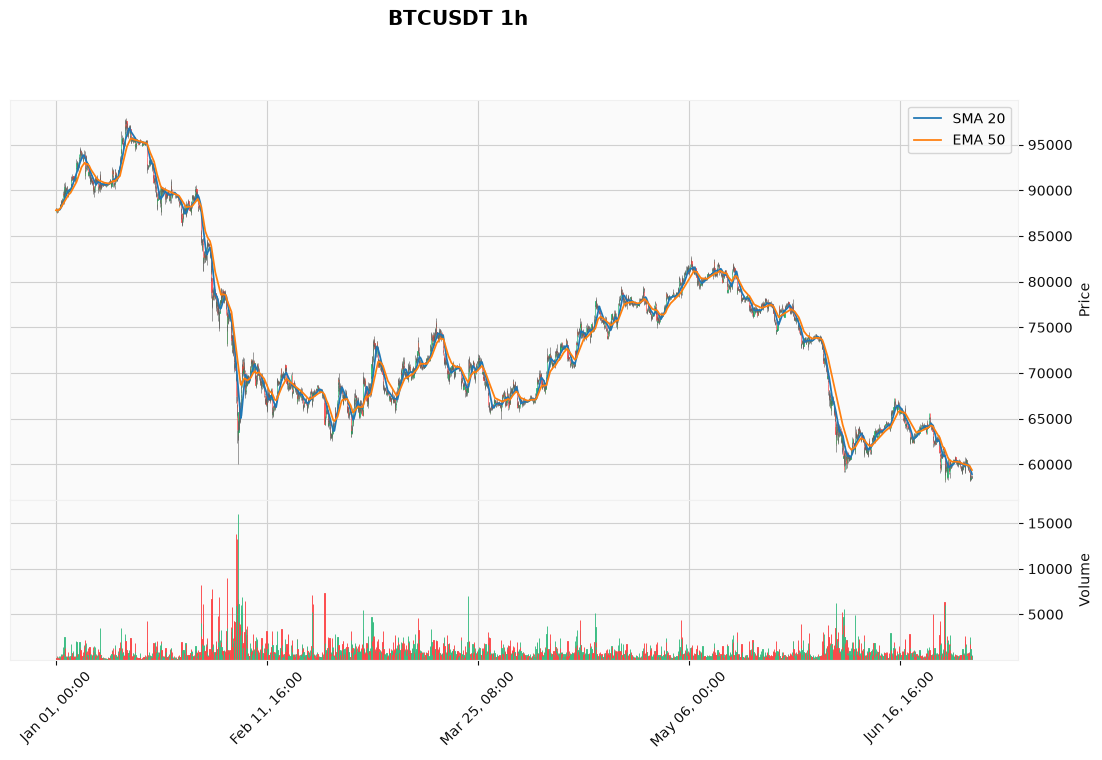

In [2]:
indicators = {
    "SMA 20": df.close.rolling(20).mean(),
    "EMA 50": df.close.ewm(span=50).mean(),
}
figure, axes = data.plot(indicators=indicators, figsize=(14, 8))

In [ ]:
from trading.strategies.sma_cross import SmaCrossConfig, backtest_sma_cross

result = backtest_sma_cross(data, SmaCrossConfig(fast_window=20, slow_window=50, fee_bps=10))
result.metrics

In [ ]:
result.trades_frame().tail(10)

In [ ]:
result.frame()[["equity", "close"]].plot(subplots=True, figsize=(14, 8), title=["Strategy equity", "BTC close"]);